In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("D:\onedrive\Desktop\CIC DDOS 2017 DATA_SET\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
#df['Destination Port']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115327 entries, 0 to 115326
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             115327 non-null  int64  
 1    Flow Duration                115327 non-null  int64  
 2    Total Fwd Packets            115327 non-null  int64  
 3    Total Backward Packets       115327 non-null  int64  
 4   Total Length of Fwd Packets   115327 non-null  int64  
 5    Total Length of Bwd Packets  115327 non-null  int64  
 6    Fwd Packet Length Max        115327 non-null  int64  
 7    Fwd Packet Length Min        115327 non-null  int64  
 8    Fwd Packet Length Mean       115327 non-null  float64
 9    Fwd Packet Length Std        115327 non-null  float64
 10  Bwd Packet Length Max         115327 non-null  int64  
 11   Bwd Packet Length Min        115327 non-null  int64  
 12   Bwd Packet Length Mean       115327 non-nul

In [5]:
X = df
X = X.drop(' Label',axis= 1)

In [6]:
y = df.iloc[:,78]

In [7]:
y

0         BENIGN
1         BENIGN
2         BENIGN
3         BENIGN
4         BENIGN
           ...  
115322      DDoS
115323      DDoS
115324      DDoS
115325      DDoS
115326      DDoS
Name:  Label, Length: 115327, dtype: object

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115327 entries, 0 to 115326
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             115327 non-null  int64  
 1    Flow Duration                115327 non-null  int64  
 2    Total Fwd Packets            115327 non-null  int64  
 3    Total Backward Packets       115327 non-null  int64  
 4   Total Length of Fwd Packets   115327 non-null  int64  
 5    Total Length of Bwd Packets  115327 non-null  int64  
 6    Fwd Packet Length Max        115327 non-null  int64  
 7    Fwd Packet Length Min        115327 non-null  int64  
 8    Fwd Packet Length Mean       115327 non-null  float64
 9    Fwd Packet Length Std        115327 non-null  float64
 10  Bwd Packet Length Max         115327 non-null  int64  
 11   Bwd Packet Length Min        115327 non-null  int64  
 12   Bwd Packet Length Mean       115327 non-nul

In [9]:
X = X.fillna(X['Flow Bytes/s'].mean())
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115327 entries, 0 to 115326
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             115327 non-null  int64  
 1    Flow Duration                115327 non-null  int64  
 2    Total Fwd Packets            115327 non-null  int64  
 3    Total Backward Packets       115327 non-null  int64  
 4   Total Length of Fwd Packets   115327 non-null  int64  
 5    Total Length of Bwd Packets  115327 non-null  int64  
 6    Fwd Packet Length Max        115327 non-null  int64  
 7    Fwd Packet Length Min        115327 non-null  int64  
 8    Fwd Packet Length Mean       115327 non-null  float64
 9    Fwd Packet Length Std        115327 non-null  float64
 10  Bwd Packet Length Max         115327 non-null  int64  
 11   Bwd Packet Length Min        115327 non-null  int64  
 12   Bwd Packet Length Mean       115327 non-nul

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [11]:
print(np.isinf(X).sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64


In [12]:
print(np.isnan(X).sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64


In [13]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace =True)

In [14]:
bad_rows = X[np.isnan(X).any(axis = 1) | np.isinf(X).any(axis=1)]

In [15]:
bad_rows

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min


In [16]:
y

0         BENIGN
1         BENIGN
2         BENIGN
3         BENIGN
4         BENIGN
           ...  
115322      DDoS
115323      DDoS
115324      DDoS
115325      DDoS
115326      DDoS
Name:  Label, Length: 115327, dtype: object

In [17]:
x_train, x_test, y_train, y_test =train_test_split(X, y, test_size=0.2, shuffle = True)

In [18]:
y_test = y_test.reset_index(drop = True)

In [19]:
y_test.shape

(23066,)

In [20]:
#x_test.info%

In [21]:
y_test.to_csv("y_test.csv")

In [22]:
# data encoding using label encoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)


x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)

In [23]:
# shuffle the y target to test model biasness\

#y_train = np.random.permutation(y_train)


In [24]:
#model 

model = LogisticRegression(max_iter = 5000)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)



In [25]:
y_pred

array([1, 0, 1, ..., 1, 1, 1])

In [26]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test,y_pred)
print("accuracy score: ",accuracy)

print("classification report: \n",classification_report(y_test, y_pred))


accuracy score:  0.9981791381253794
classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8673
           1       1.00      1.00      1.00     14393

    accuracy                           1.00     23066
   macro avg       1.00      1.00      1.00     23066
weighted avg       1.00      1.00      1.00     23066



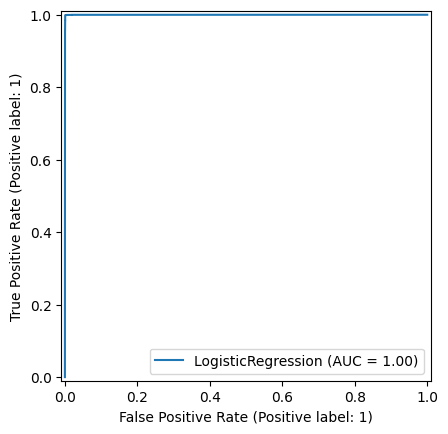

In [27]:
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, x_test, y_test)

plt.show()

In [28]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 8647    26]
 [   16 14377]]


In [29]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(model,x_test, y_test, cv =5)
print(scores.mean())

0.9933669110054499


In [31]:
#find std deviations between the five different cross value scores

print(scores)
print("std: ",scores.std())

[0.99219766 0.99414698 0.9928463  0.9939302  0.99371342]
std:  0.0007326720296030231
